# Image-Text Retrieval with Triplet Loss
**실험 구성: 초기 모델 → FC projection → MLP projection 성능 비교**

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pickle, os, copy
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. 데이터 로딩

In [53]:
#!wget -q --show-progress https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
#!unzip -q Flickr8k_Dataset.zip

IMAGE_DIR = 'Flicker8k_Dataset'

data = torch.load('flickr8k_data.pt', map_location='cpu')

img_feats = data['image_features']
glove_vectors = data['glove_vectors']
caption_ids = data['caption_ids']
caption_lengths = data['caption_lengths']
filenames = data['filenames']
captions = data['captions']
meta = data  # splits, word2idx 등도 같은 dict에 있음

print(f'Image features : {img_feats.shape}')
print(f'GloVe vectors  : {glove_vectors.shape}')
print(f'Caption IDs    : {caption_ids.shape}')
print(f'Splits — train: {len(data["splits"]["train"])}, val: {len(data["splits"]["val"])}, test: {len(data["splits"]["test"])}')

Image features : torch.Size([8091, 2048])
GloVe vectors  : torch.Size([4280, 300])
Caption IDs    : torch.Size([8091, 32])
Splits — train: 6000, val: 1000, test: 1000


## 2. Dataset & DataLoader

In [54]:
class Flickr8kDataset(Dataset):
    def __init__(self, img_feats, caption_ids, caption_lengths, indices):
        self.img_feats = img_feats[indices]
        self.caption_ids = caption_ids[indices]
        self.caption_lengths = caption_lengths[indices]

    def __len__(self):
        return len(self.img_feats)

    def __getitem__(self, idx):
        return self.img_feats[idx], self.caption_ids[idx], self.caption_lengths[idx]

train_ds = Flickr8kDataset(img_feats, caption_ids, caption_lengths, meta['splits']['train'])
test_ds = Flickr8kDataset(img_feats, caption_ids, caption_lengths, meta['splits']['test'])

BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=len(test_ds), shuffle=False)



## 3. 모델 정의

`projection` 인자로 FC와 MLP를 전환할 수 있도록 합니다.

In [55]:
class ImageEncoder(nn.Module):
    def __init__(self, input_dim=2048, embed_dim=200, projection='fc'):
        super().__init__()
        if projection == 'fc':
            self.proj = nn.Linear(input_dim, embed_dim)
        else:  # mlp
            self.proj = nn.Sequential(
                nn.Linear(input_dim, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Linear(512, embed_dim)
            )

    def forward(self, img_feat):
        return F.normalize(self.proj(img_feat), dim=-1)


class TextEncoder(nn.Module):
    def __init__(self, glove_vectors, hidden_dim=512, embed_dim=200, projection='fc'):
        super().__init__()
        self.embed = nn.Embedding.from_pretrained(glove_vectors)
        self.lstm = nn.LSTM(300, hidden_dim, batch_first=True)
        if projection == 'fc':
            self.proj = nn.Linear(hidden_dim, embed_dim)
        else:  # mlp
            self.proj = nn.Sequential(
                nn.Linear(hidden_dim, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Linear(512, embed_dim)
            )

    def forward(self, caption_ids, lengths):
        x = self.embed(caption_ids)
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (h, _) = self.lstm(packed)
        return F.normalize(self.proj(h.squeeze(0)), dim=-1)


class RetrievalModel(nn.Module):
    def __init__(self, glove_vectors, embed_dim=200, projection='fc'):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim=embed_dim, projection=projection)
        self.text_encoder = TextEncoder(glove_vectors, embed_dim=embed_dim, projection=projection)

    def forward(self, img_feat, caption_ids, lengths):
        img_emb = self.image_encoder(img_feat)
        txt_emb = self.text_encoder(caption_ids, lengths)
        return img_emb, txt_emb

## 4. Triplet Loss & 평가 & 시각화 함수

In [56]:
def triplet_loss_hard_negative(img_emb, txt_emb, margin=0.2):
    sim_matrix = img_emb @ txt_emb.t()
    positive_sim = sim_matrix.diag()
    mask = torch.eye(sim_matrix.size(0), device=sim_matrix.device).bool()

    sim_i2t = sim_matrix.masked_fill(mask, -float('inf'))
    loss_i2t = F.relu(sim_i2t.max(dim=1).values - positive_sim + margin)

    sim_t2i = sim_matrix.t().masked_fill(mask, -float('inf'))
    loss_t2i = F.relu(sim_t2i.max(dim=1).values - positive_sim + margin)

    return (loss_i2t.mean() + loss_t2i.mean()) / 2


@torch.no_grad()
def evaluate_model(model, dataloader, device):
    model.eval()
    for img_feat, cap_ids, cap_len in dataloader:
        img_emb, txt_emb = model(
            img_feat.to(device), cap_ids.to(device), cap_len.to(device)
        )
    img_emb, txt_emb = img_emb.cpu(), txt_emb.cpu()
    sim = img_emb @ txt_emb.t()

    results = {}
    for direction, s in [('I→T', sim), ('T→I', sim.t())]:
        ranks = []
        for i in range(s.size(0)):
            rank = (s[i].argsort(descending=True) == i).nonzero(as_tuple=True)[0].item()
            ranks.append(rank)
        ranks = np.array(ranks)
        results[direction] = {f'R@{k}': (ranks < k).mean() * 100 for k in [1, 5, 10]}

    for d in ['I→T', 'T→I']:
        print(f'  {d}: ' + ', '.join(f'{k}={v:.1f}' for k, v in results[d].items()))
    return results

In [57]:
@torch.no_grad()
def get_all_embeddings(model):
    """전체 데이터에 대한 embedding 추출 (시각화용)"""
    model.eval()
    all_loader = DataLoader(
        Flickr8kDataset(img_feats, caption_ids, caption_lengths, list(range(len(img_feats)))),
        batch_size=256, shuffle=False
    )
    all_img, all_txt = [], []
    for img_feat, cap_ids, cap_len in all_loader:
        img_emb, txt_emb = model(
            img_feat.to(device), cap_ids.to(device), cap_len.to(device)
        )
        all_img.append(img_emb.cpu())
        all_txt.append(txt_emb.cpu())
    return torch.cat(all_img), torch.cat(all_txt)


def show_text_to_image(query_caption, model, all_img_embs, top_k=5):
    model.eval()
    word2idx = meta['word2idx']
    tokens = query_caption.lower().split()
    ids = [word2idx.get(w, 1) for w in tokens]
    ids = ids[:32] + [0] * max(0, 32 - len(ids))
    length = min(len(tokens), 32)

    cap_tensor = torch.tensor([ids], dtype=torch.long).to(device)
    len_tensor = torch.tensor([length], dtype=torch.long).to(device)

    with torch.no_grad():
        query_emb = model.text_encoder(cap_tensor, len_tensor).cpu()

    sims = (query_emb @ all_img_embs.t()).squeeze(0)
    top_idx = sims.argsort(descending=True)[:top_k]

    print(f'Query: "{query_caption}"')
    fig, axes = plt.subplots(1, top_k, figsize=(3 * top_k, 3))
    for ax, idx in zip(axes, top_idx):
        img = Image.open(os.path.join(IMAGE_DIR, filenames[idx]))
        ax.imshow(img)
        ax.set_title(f'sim: {sims[idx]:.3f}', fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## 5. 학습 함수 정의

In [58]:
def train_model(model, num_epochs=30, lr=5e-4, margin=0.2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        for img_feat, cap_ids, cap_len in train_loader:
            img_emb, txt_emb = model(
                img_feat.to(device), cap_ids.to(device), cap_len.to(device)
            )
            loss = triplet_loss_hard_negative(img_emb, txt_emb, margin)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Epoch {epoch+1:2d}/{num_epochs}  train_loss: {train_losses[-1]:.4f}')

    return train_losses

## 6. 실험 1: 초기화 상태 (학습 전)

FC projection 모델을 만들되 학습하지 않은 상태에서 평가합니다.  
랜덤 weight이므로 검색이 전혀 작동하지 않는 것을 확인합니다.

In [59]:
EMBED_DIM = 200

model_fc = RetrievalModel(glove_vectors, embed_dim=EMBED_DIM, projection='fc').to(device)

# 파라미터를 LSTM / Image Projection / Text Projection 으로 묶어서 확인
def count_params(model):
    groups = {'LSTM': 0, 'Image Projection': 0, 'Text Projection': 0, 'Embedding (frozen)': 0}
    for name, param in model.named_parameters():
        n = param.numel()
        if 'lstm' in name:
            groups['LSTM'] += n
        elif 'image_encoder.proj' in name:
            groups['Image Projection'] += n
        elif 'text_encoder.proj' in name:
            groups['Text Projection'] += n
        elif 'embed' in name:
            groups['Embedding (frozen)'] += n
    trainable = 0
    for group, n in groups.items():
        frozen = 'frozen' in group
        status = 'FROZEN' if frozen else 'TRAIN'
        print(f'  {status:6s}  {group:25s}  {n:>10,}')
        if not frozen:
            trainable += n
    print(f'         {"Total trainable":25s}  {trainable:>10,}')

count_params(model_fc)

print('\n=== 학습 전 (랜덤 weight) ===')
evaluate_model(model_fc, test_loader, device);

  TRAIN   LSTM                        1,667,072
  TRAIN   Image Projection              409,800
  TRAIN   Text Projection               102,600
  FROZEN  Embedding (frozen)          1,284,000
         Total trainable             2,179,472

=== 학습 전 (랜덤 weight) ===
  I→T: R@1=0.1, R@5=0.5, R@10=1.3
  T→I: R@1=0.1, R@5=0.6, R@10=1.2


Query: "a dog running on the beach"


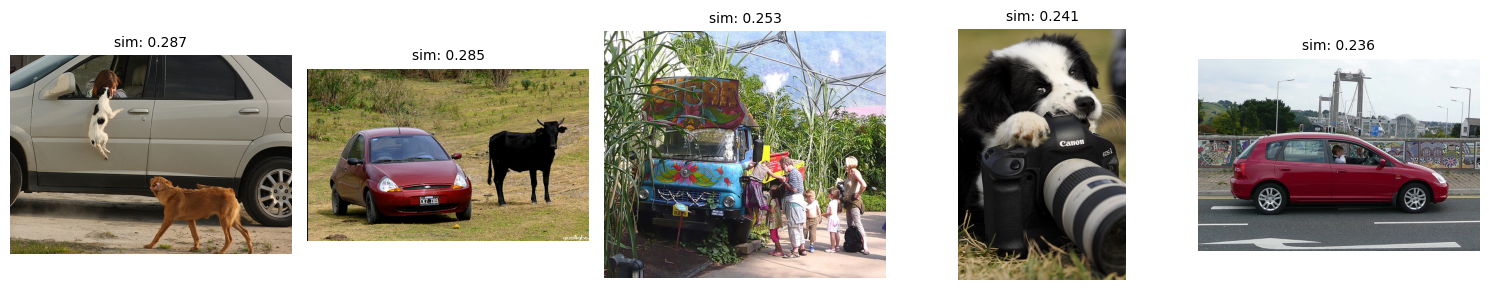

Query: "a child playing in the snow"


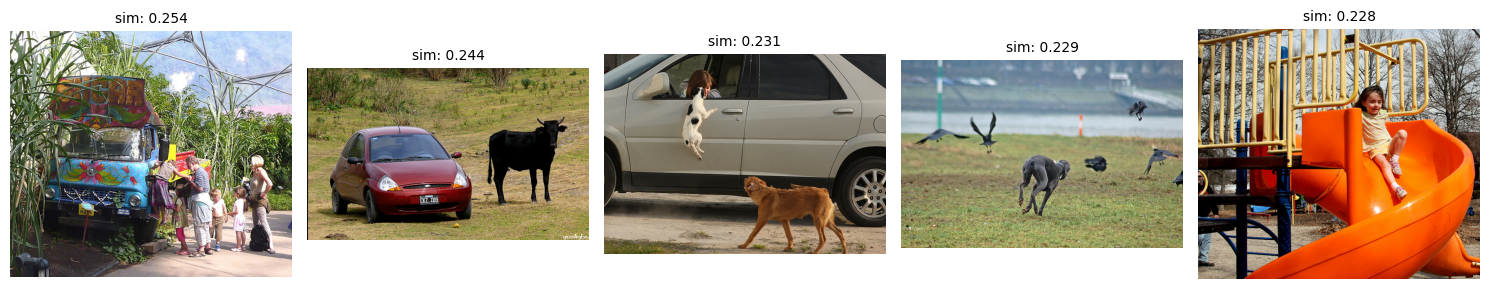

In [60]:
all_img_embs, all_txt_embs = get_all_embeddings(model_fc)
show_text_to_image('a dog running on the beach', model_fc, all_img_embs)
show_text_to_image('a child playing in the snow', model_fc, all_img_embs)

## 7. 실험 2: FC Projection (Linear)

Image: 2048 → FC → 200  
Text: LSTM hidden (512) → FC → 200

In [61]:
model_fc = RetrievalModel(glove_vectors, embed_dim=EMBED_DIM, projection='fc').to(device)

print('--- FC Projection 학습 ---')
fc_train_losses = train_model(model_fc, num_epochs=30)

--- FC Projection 학습 ---
  Epoch  1/30  train_loss: 0.2698
  Epoch  5/30  train_loss: 0.2065
  Epoch 10/30  train_loss: 0.2034
  Epoch 15/30  train_loss: 0.2023
  Epoch 20/30  train_loss: 0.2014
  Epoch 25/30  train_loss: 0.2010
  Epoch 30/30  train_loss: 0.2008


In [62]:
print('\n=== FC Projection 학습 후 ===')
evaluate_model(model_fc, test_loader, device);


=== FC Projection 학습 후 ===
  I→T: R@1=2.8, R@5=11.6, R@10=19.3
  T→I: R@1=0.4, R@5=2.0, R@10=3.2


Query: "a dog running on the beach"


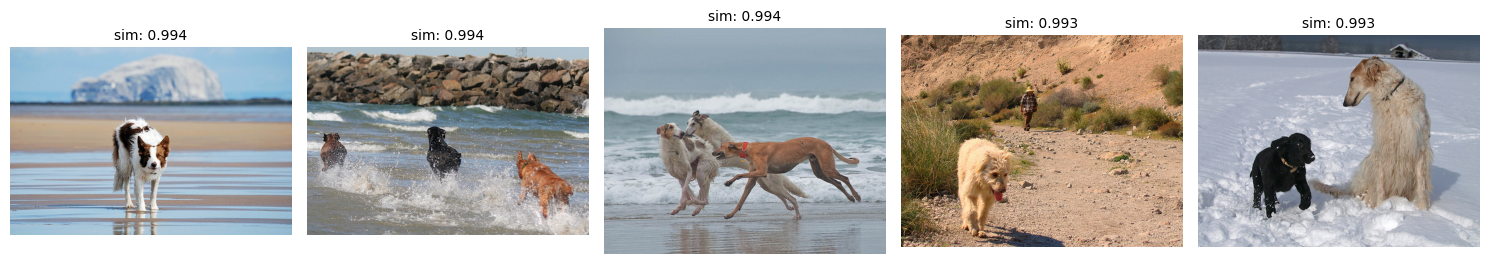

Query: "a child playing in the snow"


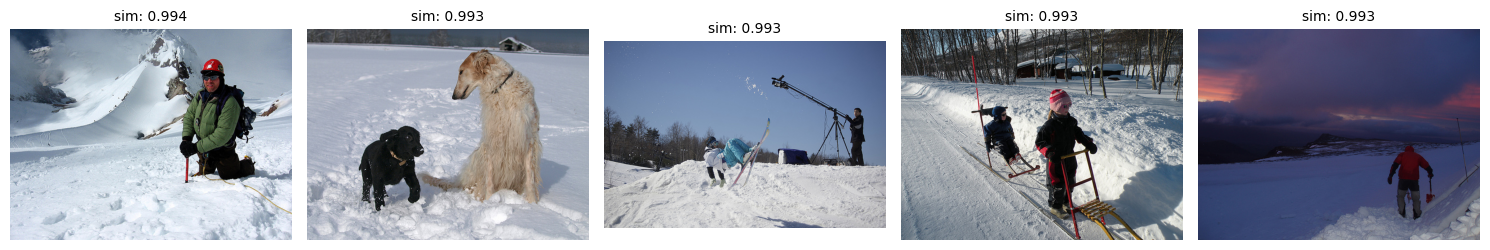

In [63]:
all_img_embs, all_txt_embs = get_all_embeddings(model_fc)
show_text_to_image('a dog running on the beach', model_fc, all_img_embs)
show_text_to_image('a child playing in the snow', model_fc, all_img_embs)

## 8. 실험 3: MLP Projection (Linear + BN + ReLU + Linear)

Image: 2048 → FC(512) → BN → ReLU → FC(200)  
Text: LSTM hidden (512) → FC(512) → BN → ReLU → FC(200)

비선형 활성화(ReLU)와 BatchNorm을 추가하면 joint space에서 벡터를 더 잘 분리할 수 있을까?

In [64]:
model_mlp = RetrievalModel(glove_vectors, embed_dim=64, projection='mlp').to(device)
count_params(model_mlp)

print('\n--- MLP Projection 학습 ---')
mlp_train_losses = train_model(model_mlp, num_epochs=30, margin=0.1)

  TRAIN   LSTM                        1,667,072
  TRAIN   Image Projection            1,082,944
  TRAIN   Text Projection               296,512
  FROZEN  Embedding (frozen)          1,284,000
         Total trainable             3,046,528

--- MLP Projection 학습 ---
  Epoch  1/30  train_loss: 0.2061
  Epoch  5/30  train_loss: 0.1006
  Epoch 10/30  train_loss: 0.0856
  Epoch 15/30  train_loss: 0.0222
  Epoch 20/30  train_loss: 0.0053
  Epoch 25/30  train_loss: 0.0028
  Epoch 30/30  train_loss: 0.0024


In [65]:
print('\n=== MLP Projection 학습 후 ===')
evaluate_model(model_mlp, test_loader, device);


=== MLP Projection 학습 후 ===
  I→T: R@1=5.8, R@5=18.4, R@10=28.3
  T→I: R@1=6.3, R@5=19.0, R@10=26.7


Query: "a dog running on the beach"


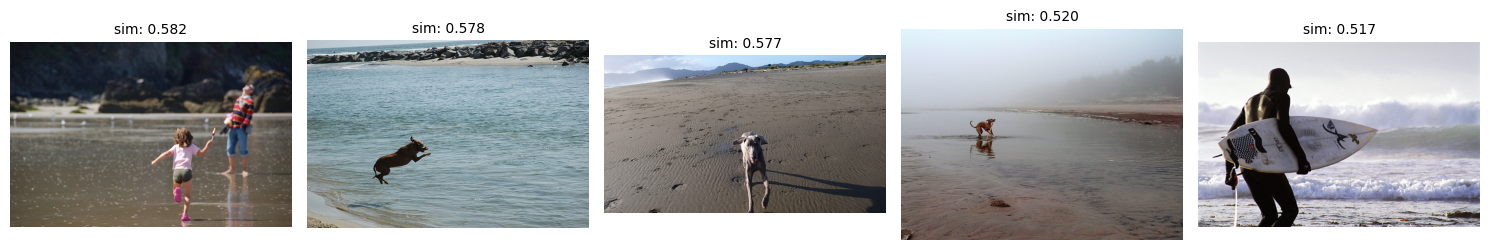

Query: "a child playing in the snow"


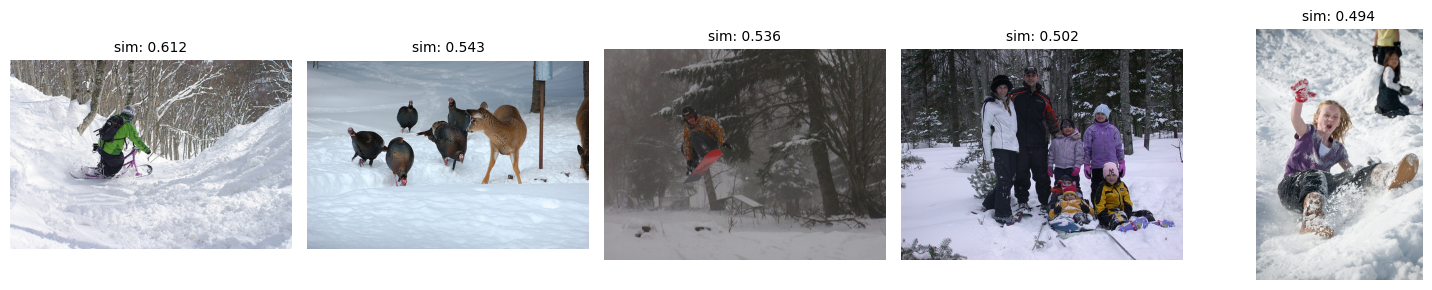

In [66]:
all_img_embs, all_txt_embs = get_all_embeddings(model_mlp)
show_text_to_image('a dog running on the beach', model_mlp, all_img_embs)
show_text_to_image('a child playing in the snow', model_mlp, all_img_embs)

## 9. 비교 정리

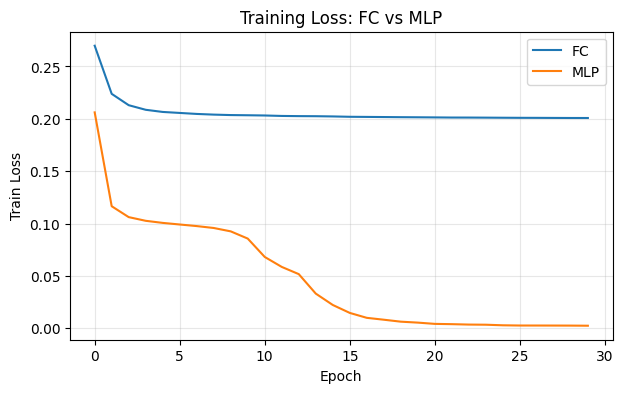

In [67]:
# Training curve 비교
plt.figure(figsize=(7, 4))
plt.plot(fc_train_losses, label='FC')
plt.plot(mlp_train_losses, label='MLP')
plt.xlabel('Epoch'); plt.ylabel('Train Loss')
plt.title('Training Loss: FC vs MLP')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

In [68]:
print('=== 최종 비교 (Test set) ===\n')
print('FC Projection:')
evaluate_model(model_fc, test_loader, device);
print('\nMLP Projection:')
evaluate_model(model_mlp, test_loader, device);

=== 최종 비교 (Test set) ===

FC Projection:
  I→T: R@1=2.8, R@5=11.6, R@10=19.3
  T→I: R@1=0.4, R@5=2.0, R@10=3.2

MLP Projection:
  I→T: R@1=5.8, R@5=18.4, R@10=28.3
  T→I: R@1=6.3, R@5=19.0, R@10=26.7
